<a href="https://colab.research.google.com/github/muneer-ahmad10/Natural-Language-processing/blob/main/Resume_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install Everything**

In [17]:
!pip install PyPDF2

In [18]:
!pip install spacy scikit-learn sentence-transformers
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 51.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# **Upload Resume File**

In [19]:
from google.colab import files

uploaded = files.upload()

Saving Document (1).pdf to Document (1) (1).pdf


# **Extract Text from PDF**

In [20]:
import PyPDF2

def extract_text_from_pdf(file):
    reader = PyPDF2.PdfReader(file)
    text = ""

    for page in reader.pages:
        text += page.extract_text()

    return text

In [21]:
file_name = list(uploaded.keys())[0]

resume_text = extract_text_from_pdf(file_name)

print(resume_text[:500])  # preview first 500 characters

MUNEEER AHMAD DAR  
Aspiring Data Analyst | ML Fundamentals  
India | (91) 95410 -51960 | abrard855@gmail.com  | LinkedIn: /muneerahmad -826363267  | 
GitHub: /muneer -ahmad10  
 
PROFESSIONAL SUMMARY  
Highly motivated and results -driven Fresher  with a strong foundation in Data 
Analysis, Exploratory Data Analysis (EDA),  and Machine Learning fundamentals . 
Proficient in utilizing Python (Pandas, NumPy, Matplotlib, Seaborn, Scikit -learn)  and 
SQL  for data cleaning, visualization, model bu


# **Preprocessing**

In [22]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9]', ' ', text)
    text = " ".join(text.split())
    return text

# **Skills Extraction**

In [23]:
# SKILLS_DB = [
#     "python", "machine learning", "deep learning",
#     "nlp", "pytorch", "tensorflow", "sql",
#     "data analysis", "api", "docker"
# ]

def extract_skills(text):
    text = text.lower()
    return list(set([skill for skill in SKILLS_DB if skill in text]))

# **Similarity**

In [24]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')

def compute_similarity(resume, job):
    emb1 = model.encode([resume])
    emb2 = model.encode([job])
    score = cosine_similarity(emb1, emb2)[0][0]
    return round(score * 100, 2)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# **Main Execution**

In [25]:
Data_science_job_desc=''' Job Description:

Position / Title/ Name: Data Scientist

Department: Digital Products & Services / Integrated Information Technology (IIT)

Experience: 5 Years+

Job Location: Gurugram (Hybrid)



Strategic purpose of the position:

The Data Scientist works closely with AI Data Engineers, software engineers, and business stakeholders to develop, deploy, and scale AI models and enterprise-grade GenAI applications. This includes building retrieval and agentic solutions on Azure using secure, production-ready services such as Azure AI Search, Document Intelligence, Azure OpenAI / AI Foundry, Cosmos DB, Redis, Blob Storage, and Microsoft 365 integrations, while ensuring responsible, trustworthy, and seamless AI adoption across the company landscape.



Personal qualifications / competencies:

Core Technical Skills:

·      Strong analytical and problem-solving skills

·      Strong Python proficiency, including:

o  Data pre- and post-processing

o  Pipeline development and optimization

o  API integrations

o  Optimization techniques (e.g., PuLP)

o  Basic testing and code quality practices

·      Proven experience in data science, statistical modeling, and machine learning

·      Hands-on experience with ML and data libraries such as Scikit-learn, XGBoost, PyTorch, TensorFlow, Pandas, NumPy

·      Experience preprocessing and optimizing structured and unstructured datasets to make them LLM-ready

·      Experience with GenAI and agentic frameworks, including:

o  Prompt engineering

o  RAG (Retrieval-Augmented Generation)

o  Multi-agent systems

o  MCP servers

o  Frameworks such as Autogen and OpenAI API integrations

o  Experience building enterprise GenAI and multi-agent solutions using Azure Bot Service, Azure Service Bus, Azure Container Apps / Jobs, and ACI-based sandbox execution

o  Experience with retrieval pipelines using Azure AI Search, vector search, hybrid retrieval, reranking, and enterprise knowledge sources

o  Hands-on experience with LLM evaluation, prompt iteration, and groundedness / answer quality validation for production use cases



Data & Platform Skills:

·      Working knowledge of SQL (e.g., SELECT, JOIN, GROUP BY) and familiarity with NoSQL concepts

·      Experience with data pipelines, ETL/ELT processes, and orchestration tools (experience with Microsoft Fabric is a strong plus)

·      Familiarity with MLOps practices, including model deployment, monitoring, and lifecycle management

·      Hands-on experience with cloud platforms, preferably Azure, including:

·      Azure AI services such as Azure AI Search, Azure Document Intelligence, Azure OpenAI / AI Foundry, and related cognitive services

·      Azure AI Foundry

·      Copilot Studio

·      Experience with Microsoft 365 and enterprise integration layers including Microsoft Teams, Microsoft Entra ID, SharePoint, Microsoft Graph API, and role-based access control

·      Understanding of secure Azure architecture patterns including private endpoints, managed identities, Azure Key Vault, Azure Container Registry, and network-isolated workloads

·      Experience with observability and operations using Log Analytics, Application Insights, continuous evaluations, and production monitoring / alerting

·      Data storage and retrieval solutions such as Azure Blob Storage, PostgreSQL, Azure Cosmos DB, Azure Managed Redis, and Microsoft OneLake / Fabric

·      Familiarity with standard development tools and practices, including Git

Visualization & Communication

·      Experience with data visualization and storytelling using tools such as Power BI, Tableau, or Python-based dashboards (Dash, Streamlit)

·      Strong ability to translate business problems into analytical and AI-driven solutions

·      Fluent English communication skills, both written and verbal



Architecture & Responsible AI:

·      Ability to define integration points across products to ensure end-to-end application flow

·      Commitment to building responsible, trustworthy, and ethical AI solutions within the company landscape

·      Ability to work with secure-by-design patterns including secrets management, model access controls, outbound restrictions, and DevSecOps practices

·      Ability to translate solution architecture into production-ready AI applications spanning APIs, data stores, evaluation pipelines, and enterprise integrations



Educational / minimum requirements:

·      Master’s degree in Data Science, Statistics, Mathematics, Computer Science, or a related field

·      Relevant certifications in machine learning, analytics, Azure, Microsoft AI, or cloud platforms are advantageous

Job responsibilities:

·      Identify opportunities to apply data science and GenAI across business functions

·      Develop and deploy predictive and prescriptive models for use cases across Company commercial, supply chain, and operations

·      Work with large datasets to clean, analyze, and visualize trends, patterns, and drivers

·      Collaborate with business stakeholders to frame problems and deliver data-driven insights

·      Deploy AI/ML models into production and monitor performance over time

·      Work closely with AI Data Engineers and software teams to integrate models into AI-driven applications

·      Document methodologies, architectures, and results for both technical and non-technical audiences

·      Contribute to the scaling of AI and GenAI capabilities across the organization

·      Build and support enterprise AI solutions across Microsoft Teams and web channels using bot, agent, and workflow orchestration patterns

·      Design retrieval pipelines across SharePoint, OneLake / Fabric, ERP / CSV sources, and other enterprise repositories to enable grounded GenAI experiences

·      Work with platform teams to productionize secure Azure deployments using Container Apps, Service Bus, Key Vault, private endpoints, and managed identities

·      Define and monitor evaluation, observability, and alerting mechanisms using Application Insights, Log Analytics, and continuous evaluation practices

Required Leadership behaviors:

Alignment

·      - Frames data science work around key business priorities

·      - Collaborates with stakeholders to ensure adoption and impact

Accountability

·      - Delivers analytical solutions with measurable business outcomes

·      - Demonstrates rigor in experimentation and model evaluation

Action

·      - Proactively explores data for insights and opportunities

·      - Applies creativity and critical thinking to solve business problems'''

In [26]:
# import spacy

# nlp = spacy.load("en_core_web_sm")

# # def extract_skills_from_job(job_text):
# #     doc = nlp(job_text.lower())

# #     skills = []

# #     for token in doc:
# #         # Keep only meaningful words
# #         if token.pos_ in ["NOUN", "PROPN"]:
# #             skills.append(token.text)

# #     return list(set(skills))

# STOP_WORDS_EXTRA = [
#     "experience", "role", "team", "work",
#     "looking", "developer", "engineer"
# ]

# def extract_skills_from_job(job_text):
#     doc = nlp(job_text.lower())

#     skills = []

#     for token in doc:
#         if token.pos_ in ["NOUN", "PROPN"]:
#             if token.text not in STOP_WORDS_EXTRA:
#                 skills.append(token.text)

#     return list(set(skills))

In [27]:
#comprehensive list of technical skills to look for
SKILLS_DB = [
    "python", "machine learning", "statistical modeling", "scikit-learn",
    "xgboost", "pytorch", "tensorflow", "pandas", "numpy", "genai",
    "rag", "azure", "sql", "nosql", "mlops", "power bi", "tableau",
    "streamlit", "git", "api", "cosmos db", "docker", "nlp"
]

def extract_skills(text):
    text = text.lower()
    #checks if the specific skill exists in the text
    found_skills = [skill for skill in SKILLS_DB if skill in text]
    return list(set(found_skills))

# specific functions to use this new logic
def extract_skills_from_job(job_text):
    return extract_skills(job_text)

def extract_skills_from_resume(resume_text):
    return extract_skills(resume_text)

In [28]:
# def extract_skills_from_resume(resume_text):
#     doc = nlp(resume_text.lower())

#     skills = []

#     for token in doc:
#         if token.pos_ in ["NOUN", "PROPN"]:
#             skills.append(token.text)

#     return list(set(skills))

In [29]:
# resume = resume_text

# job = Data_science_job_desc

# # Clean
# resume_clean = clean_text(resume)
# job_clean = clean_text(job)

# # Missing
# missing_skills = list(set(job_skills) - set(resume_skills))

# # Similarity
# score = compute_similarity(resume_clean, job_clean)

# # job_skills = extract_skills_from_job(job)
# # resume_skills = extract_skills_from_resume(resume)

# # matched = list(set(job_skills) & set(resume_skills))
# # missing = list(set(job_skills) - set(resume_skills))

# # print("Matched:", matched)
# # print("Missing:", missing)

# # print("Match Score:", score, "%")
# # print("Resume Skills:", resume_skills)
# # print("Missing Skills:", missing_skills)
# # ... after computing similarity score ...

# # Use the cleaned text for everything to stay consistent
# job_skills = extract_skills_from_job(job_clean)
# resume_skills = extract_skills_from_resume(resume_clean)

# matched = list(set(job_skills) & set(resume_skills))
# missing = list(set(job_skills) - set(resume_skills))

# print(f"Match Score: {score}%")
# print(f"Matched Skills: {matched}")
# print(f"Missing Skills: {missing}")

In [30]:
# 1. Prepare the text
resume = resume_text
job = Data_science_job_desc

# 2. Clean the text
resume_clean = clean_text(resume)
job_clean = clean_text(job)

# 3. Extract skills using your new functions
job_skills = extract_skills_from_job(job_clean)
resume_skills = extract_skills_from_resume(resume_clean)

# 4. Calculate metrics
matched = list(set(job_skills) & set(resume_skills))
missing = list(set(job_skills) - set(resume_skills))
score = compute_similarity(resume_clean, job_clean)

# 5. Print Results
print(f"--- Analysis Results ---")
print(f"Match Score: {score}%")
print(f"Matched Skills: {matched}")
print(f"Missing Skills: {missing}")

--- Analysis Results ---
Match Score: 71.31999969482422%
Matched Skills: ['numpy', 'pandas', 'sql', 'rag', 'machine learning', 'git', 'python']
Missing Skills: ['tableau', 'statistical modeling', 'tensorflow', 'api', 'mlops', 'xgboost', 'azure', 'nosql', 'pytorch', 'genai', 'power bi', 'cosmos db', 'streamlit']


# **Visualization**

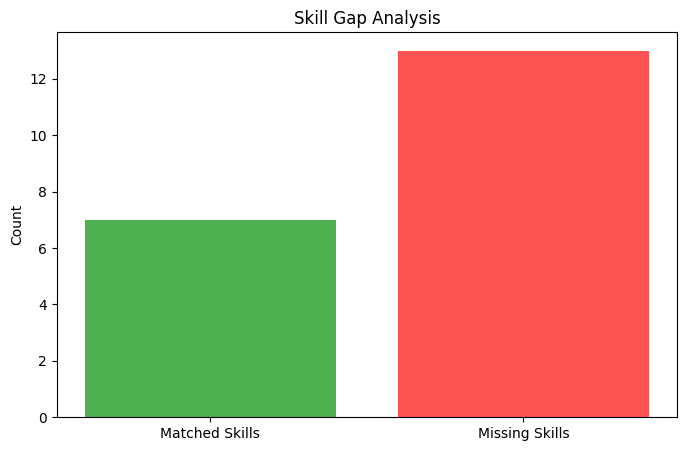

In [31]:
import matplotlib.pyplot as plt

labels = ['Matched Skills', 'Missing Skills']
counts = [len(matched), len(missing)]

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color=['#4CAF50', '#FF5252'])
plt.title('Skill Gap Analysis')
plt.ylabel('Count')
plt.show()